In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
df_tesla = pd.read_csv('../data/TESLA Search Trend vs Price.csv')

df_btc_search = pd.read_csv('../data/Bitcoin Search Trend.csv')
df_btc_price = pd.read_csv('../data/Daily Bitcoin Price.csv')

df_unemployment = pd.read_csv('../data/UE Benefits Search vs UE Rate 2004-19.csv')

In [19]:
df_tesla.head(1)

,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
0,2010-06-01,3,4.766


In [20]:
df_btc_search.head(1)

,MONTH,BTC_NEWS_SEARCH
0,2014-09,5


In [21]:
df_btc_price.head(1)

,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,21056800.0


In [22]:
df_unemployment.head(1)

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01,34,5.7


## Data Cleaning

### Missing Values

In [10]:
print(df_tesla.isna().any())
print(df_btc_search.isna().any())
print(df_btc_price.isna().any())
print(df_unemployment.isna().any())

MONTH              False
TSLA_WEB_SEARCH    False
TSLA_USD_CLOSE     False
dtype: bool
MONTH              False
BTC_NEWS_SEARCH    False
dtype: bool
DATE      False
CLOSE      True
VOLUME     True
dtype: bool
MONTH                     False
UE_BENEFITS_WEB_SEARCH    False
UNRATE                    False
dtype: bool


In [17]:
print(df_btc_price.isna().sum())
print(df_btc_price[df_btc_price.CLOSE.isna()])
print(df_btc_price[df_btc_price.VOLUME.isna()])

DATE      0
CLOSE     1
VOLUME    1
dtype: int64
            DATE  CLOSE  VOLUME
2148  2020-08-04    NaN     NaN
            DATE  CLOSE  VOLUME
2148  2020-08-04    NaN     NaN


#### Removing Missing Values

In [18]:
df_btc_price.dropna(inplace=True)

### Date

### Convert to DateTime

In [23]:
df_tesla.MONTH = pd.to_datetime(df_tesla.MONTH)
df_btc_search.MONTH = pd.to_datetime(df_btc_search.MONTH )
df_btc_price.DATE = pd.to_datetime(df_btc_price.DATE)
df_unemployment.MONTH = pd.to_datetime(df_unemployment.MONTH)

### Convert to Monthly

In [30]:
df_btc_monthly = df_btc_price.resample('ME', on='DATE').mean()

## Visualization

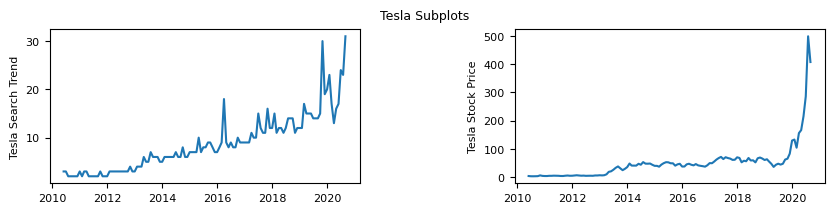

In [70]:
fig, axes = plt.subplots(1,2, figsize=(10,2))

x = df_tesla.MONTH
y1 = df_tesla.TSLA_WEB_SEARCH
y2 = df_tesla.TSLA_USD_CLOSE

axes[0].plot(x,y1)
axes[1].plot(x,y2)

axes[0].set_ylabel('Tesla Search Trend', fontsize=8)
axes[1].set_ylabel('Tesla Stock Price', fontsize=8)

axes[0].tick_params(axis='both', labelsize=8)
axes[1].tick_params(axis='both', labelsize=8)

fig.suptitle('Tesla Subplots', fontsize=9)
fig.subplots_adjust(wspace=0.5)

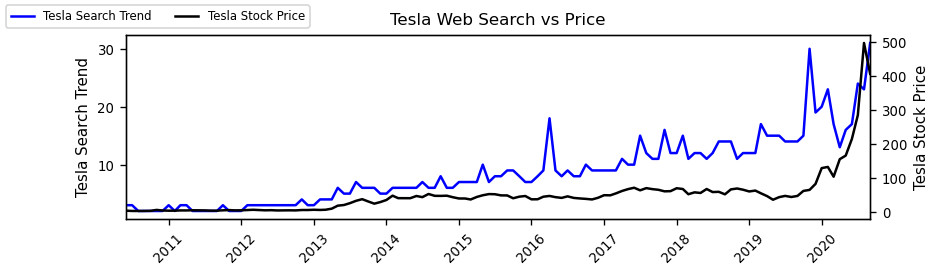

In [82]:
fig, ax = plt.subplots(figsize=(8,2), dpi=120)

ax2 = ax.twinx()

ax_label = 'Tesla Search Trend'
ax2_label = 'Tesla Stock Price'

ax.plot(x,y1, label= ax_label, color= 'blue')
ax2.plot(x,y2, label= ax2_label, color= 'black')

ax.set_title('Tesla Web Search vs Price', fontsize=10)

ax.set_ylabel(ax_label, fontsize=9)
ax2.set_ylabel(ax2_label, fontsize=9)

ax.tick_params(axis='both', labelsize=8)
ax2.tick_params(axis='both', labelsize=8)
ax.tick_params(axis='x', labelrotation=45)

ax.set_xlim(df_tesla.MONTH.min(), df_tesla.MONTH.max())
fig.legend(loc='upper left', fontsize=7, ncol=2)